In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


**Transform and Normalize to eliminate scale differences**

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])


**Dataset Pre-processing /Pre-training splits**

In [5]:
full_train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


**Baseline CNN with Minimal Architecture**

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc = nn.Linear(16 * 16 * 16, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x



**Enhanced CNN Architecture**

- Includes batch normalization
- Additional Layers (MLP)

In [7]:
class ExtendedCNN(nn.Module):
    def __init__(self):
        super(ExtendedCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc = nn.Linear(32 * 8 * 8, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


Define Training Function

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, device='cpu'):

    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):

        #Training Step

        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation Step

        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        # Store metrics

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies


**Training Models : Baseline CNN and Enhanced CNN**

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

criterion = nn.CrossEntropyLoss()

# Baseline CNN
baseline_model = BaselineCNN()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

b_train_loss, b_val_loss, b_train_acc, b_val_acc = train_model(
    baseline_model, train_loader, val_loader, criterion, optimizer, epochs=10, device=device
)

# Extended CNN
extended_model = ExtendedCNN()
optimizer = optim.Adam(extended_model.parameters(), lr=0.001)

e_train_loss, e_val_loss, e_train_acc, e_val_acc = train_model(
    extended_model, train_loader, val_loader, criterion, optimizer, epochs=10, device=device
)


Epoch 1: Train Loss=1.5012, Train Acc=47.30% | Val Loss=1.3044, Val Acc=55.15%
Epoch 2: Train Loss=1.2318, Train Acc=56.97% | Val Loss=1.2403, Val Acc=57.09%
Epoch 3: Train Loss=1.1371, Train Acc=60.36% | Val Loss=1.2014, Val Acc=58.36%
Epoch 4: Train Loss=1.0721, Train Acc=63.13% | Val Loss=1.1823, Val Acc=58.78%
Epoch 5: Train Loss=1.0212, Train Acc=64.86% | Val Loss=1.1305, Val Acc=60.61%
Epoch 6: Train Loss=0.9840, Train Acc=65.94% | Val Loss=1.1080, Val Acc=61.89%
Epoch 7: Train Loss=0.9485, Train Acc=67.40% | Val Loss=1.1017, Val Acc=61.55%
Epoch 8: Train Loss=0.9205, Train Acc=68.11% | Val Loss=1.0927, Val Acc=62.47%
Epoch 9: Train Loss=0.8957, Train Acc=69.04% | Val Loss=1.0961, Val Acc=62.92%
Epoch 10: Train Loss=0.8748, Train Acc=70.04% | Val Loss=1.1070, Val Acc=62.80%
Epoch 1: Train Loss=1.3466, Train Acc=52.57% | Val Loss=1.1121, Val Acc=61.01%
Epoch 2: Train Loss=1.0267, Train Acc=64.17% | Val Loss=1.0004, Val Acc=64.87%
Epoch 3: Train Loss=0.9319, Train Acc=67.50% | Val 

**Plot Loss and Accuracy for both models**

Text(0.5, 1.0, 'Training vs Validation Accuracy')

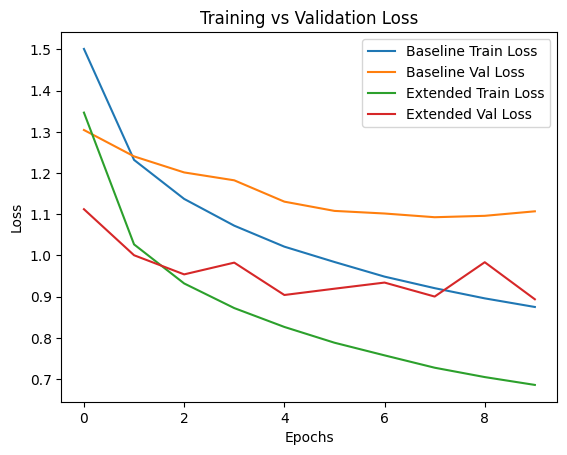

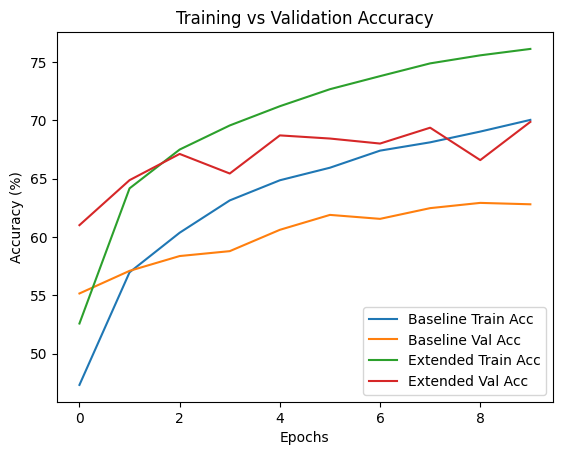

In [10]:
# Loss Plot
plt.figure()
plt.plot(b_train_loss, label="Baseline Train Loss")
plt.plot(b_val_loss, label="Baseline Val Loss")
plt.plot(e_train_loss, label="Extended Train Loss")
plt.plot(e_val_loss, label="Extended Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

# Accuracy Plot
plt.figure()
plt.plot(b_train_acc, label="Baseline Train Acc")
plt.plot(b_val_acc, label="Baseline Val Acc")
plt.plot(e_train_acc, label="Extended Train Acc")
plt.plot(e_val_acc, label="Extended Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Training vs Validation Accuracy")


**Final Task : Model Evaluation**

In [11]:
def evaluate_test(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


baseline_test_acc = evaluate_test(baseline_model, test_loader, device)
extended_test_acc = evaluate_test(extended_model, test_loader, device)

print(f"Baseline CNN Test Accuracy: {baseline_test_acc:.2f}%")
print(f"Extended CNN Test Accuracy: {extended_test_acc:.2f}%")


Baseline CNN Test Accuracy: 62.98%
Extended CNN Test Accuracy: 70.33%


**Task 1 - Explainations**

The dataset used in this experiment is CIFAR-10, which consists of 60,000 colour images distributed across 10 object classes (such as airplane, automobile, bird, cat). Each image has a fixed dimension of 32 × 32 pixels with 3 colour channels ( Red, Blue and Green),  suitable for feature extraction using a CNN.

CIFAR-10 is appropriate for CNN modelling because It is sufficiently complex to demonstrate feature hierarchy learning, yet small enough for efficient experimentation


**Task 2 - Explainations**

1. **Baseline CNN (Simple Architecture)**


The baseline CNN was intentionally designed to be simple and shallow, consisting of:

- One convolutional layer

- One max-pooling layer

- One fully connected output layer

- The convolutional layer learns low level visual features, such as edges and colour gradients, by applying learnable filters across the image. These filters detect patterns regardless of their position, enabling spatial generalization.

- The maxpooling layer reduces the spatial dimensions of the feature maps, which Lowers computational complexity , Retains the most dominant features, Introduces a degree of translation invariance

- The fully connected layer maps extracted features into class probabilities for classification.

This minimal architecture serves as a baseline benchmark, allowing clear comparison with more advanced designs.

**Task 3 - Explainations**

2. **Extended CNN (Architectural Improvement)**

The extended CNN introduces the following modifications:

- An additional convolutional layer

- Batch normalization after each convolution

- These changes were made to improve the model’s ability to learn more complex and hierarchical features.

- The second convolutional layer allows the network to move beyond simple edge detection and capture higher-level structures, such as object parts and textures.

- Batch normalization stabilizes training by normalizing intermediate activations, which Reduces internal covariate shift and allows higher learning rates mproving convergence speed and generalization

**Expected Benefits include :**

- Improved feature representation

- Faster and more stable training

- Higher classification accuracy

- Potential Risks

- Increased model complexity may lead to overfitting

- Higher computational cost

- Diminishing returns if depth increases without proper regularization


**Task 4 - Training Behaviour Analysis**

**Baseline CNN**

- Train Loss = 0.8748 | Train Accuracy = 70.04%
- Validation Loss = 1.1070 | Validation Accuracy = 62.80%

**Extended CNN**

- Train Loss = 0.6856 | Train Accuracy = 76.13%
- Validation Loss = 0.8935 | Validation Accuracy = 69.87%

**Analysis**

- The baseline CNN shows stable learning, with decreasing training loss and moderate accuracy. However, the gap between training accuracy (70.04%) and validation accuracy (62.80%) indicates limited generalization capacity.

- The extended CNN demonstrates improved performance across all metrics. Lower training and validation loss, along with higher accuracies, indicate more effective feature learning and better convergence.

**The validation performance improvement (+7.07%) suggests that:**

- Additional convolution layers enhance feature hierarchy learning

- Batch normalization improves training stability and generalization

**Key Insight**

The extended architecture improves not only accuracy but also training efficiency and stability, confirming the impact of architectural design on learning dynamics.

**Task 5 - Controlled Test Set Evaluation**

**Final Task results**

- Baseline CNN Test Accuracy: 62.98%

- Extended CNN Test Accuracy: 70.33%

Analysis

The test results are consistent with validation performance:

Baseline model: validation (62.80%) ≈ test (62.98%)

Extended model: validation (69.87%) ≈ test (70.33%)

**Key Insight**

Performance gains are supported by both validation and test results, indicating that improvements are due to better model design, not random variation.

